# **Import the data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt


# Load CLEAN dataset (important)
file_path = "/content/drive/MyDrive/atl_joined_weather_flights_2024.csv"
print("Drive mounted succesefully")

df = pd.read_csv(file_path)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted succesefully!


In [ ]:
print(df.head())
print(df.columns)
print(df.shape)


   month  day_of_month op_unique_carrier origin dest  crs_dep_time  \
0      1             1                9E    ATL  TLH           920   
1      1             1                9E    TLH  ATL          1114   
2      1             1                9E    ATL  DHN          1355   
3      1             1                9E    DHN  ATL          1446   
4      1             1                9E    DHN  ATL           648   

   crs_arr_time  dep_delay  arr_delay  cancelled  ...  Wind_Min_mph  \
0          1029       -5.0       -6.0          0  ...             5   
1          1225       -5.0      -13.0          0  ...             5   
2          1401       -3.0      -13.0          0  ...             5   
3          1702      -10.0      -26.0          0  ...             5   
4           854       -6.0       10.0          0  ...             5   

   Pressure_Max_in  Pressure_Avg_in  Pressure_Min_in  Precip_Total_in  \
0             29.1             29.0             29.0              0.0   
1     

# **% of flights that have a departure delay due to a weather**

weather_severity_flag
0    0.172061
1    0.250609
Name: dep_delayed_15, dtype: float64


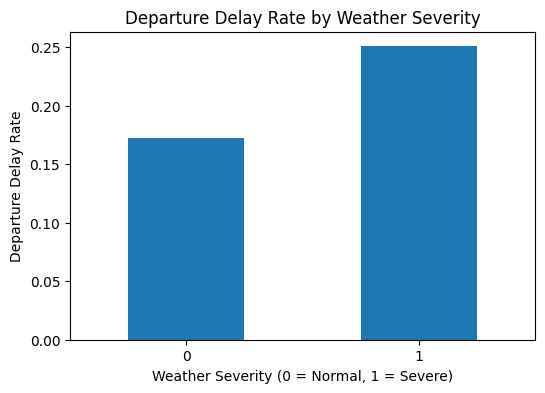

In [ ]:
cancel_rates = df.groupby("weather_severity_flag")["dep_delayed_15"].mean()
print(cancel_rates)

plt.figure(figsize=(6,4))

cancel_rates.plot(kind="bar")

plt.title("Departure Delay Rate by Weather Severity")
plt.xlabel("Weather Severity (0 = Normal, 1 = Severe)")
plt.ylabel("Departure Delay Rate")
plt.xticks(rotation=0)

plt.show()

# **Average arrival delay by airline**

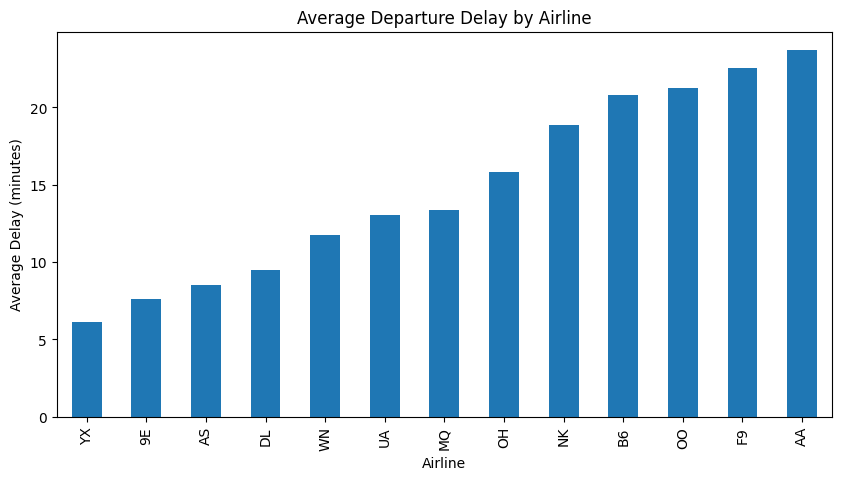

In [ ]:
#
plt.figure(figsize=(10,5))

df.groupby("op_unique_carrier")["dep_delay"].mean().sort_values().plot(kind="bar")

plt.title("Average Departure Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (minutes)")
plt.show()

| Code | Airline Name        |
|------|----------------------|
| YX   | Republic Airways     |
| 9E   | Endeavor Air         |
| AS   | Alaska Airlines      |
| DL   | Delta Air Lines      |
| WN   | Southwest Airlines   |
| UA   | United Airlines      |
| MQ   | Envoy Air            |
| OH   | PSA Airlines         |
| NK   | Spirit Airlines      |
| B6   | JetBlue Airways      |
| OO   | SkyWest Airlines     |
| F9   | Frontier Airlines    |
| AA   | American Airlines    |


# **Departure Delay Rate by Hour**

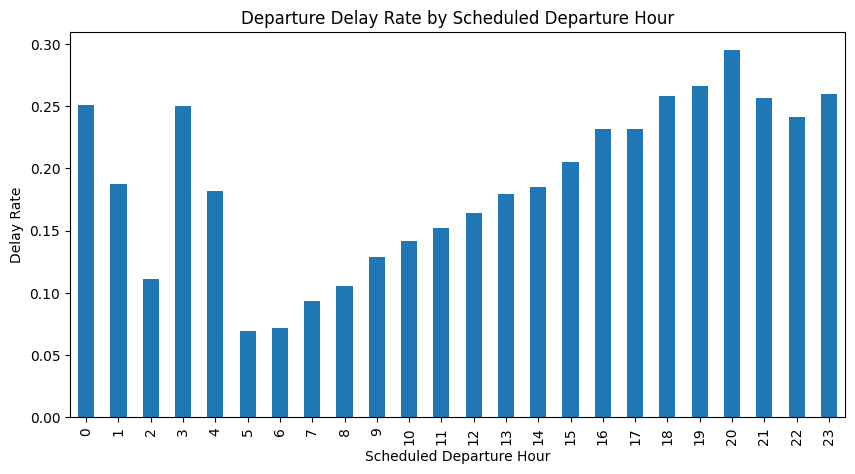

In [ ]:
plt.figure(figsize=(10,5))

df.groupby("sched_dep_hour")["dep_delayed_15"].mean().plot(kind="bar")

plt.title("Departure Delay Rate by Scheduled Departure Hour")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Delay Rate")
plt.show()

# **With severe weather, how much longer of a delay will there be**

<Figure size 800x500 with 0 Axes>

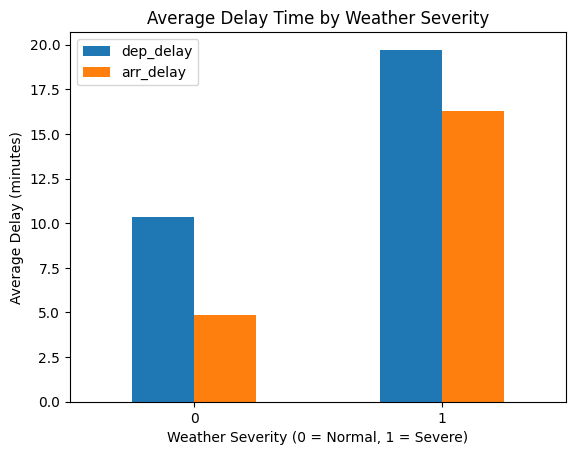

In [ ]:
plt.figure(figsize=(8,5))

df.groupby("weather_severity_flag")[["dep_delay", "arr_delay"]].mean().plot(kind="bar")

plt.title("Average Delay Time by Weather Severity")
plt.xlabel("Weather Severity (0 = Normal, 1 = Severe)")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=0)

plt.show()

# **Weather Severity Impact**

<Figure size 800x500 with 0 Axes>

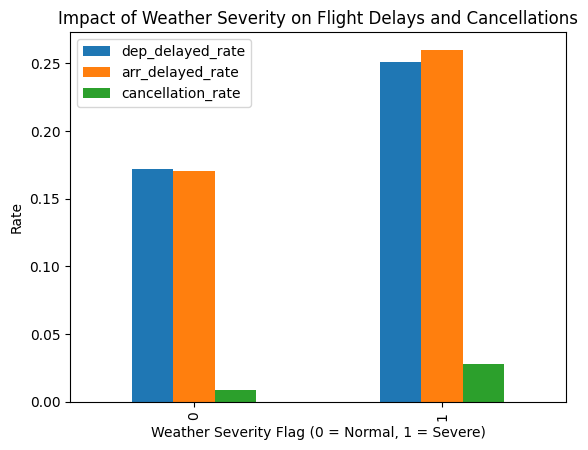

In [ ]:
df_plot = (
    df.groupby("weather_severity_flag")[["dep_delayed_15", "arr_delayed_15", "cancelled"]]
      .mean()
      .rename(columns={
          "dep_delayed_15": "dep_delayed_rate",
          "arr_delayed_15": "arr_delayed_rate",
          "cancelled": "cancellation_rate"
      })
)

plt.figure(figsize=(8,5))
df_plot.plot(kind="bar")

plt.title("Impact of Weather Severity on Flight Delays and Cancellations")
plt.xlabel("Weather Severity Flag (0 = Normal, 1 = Severe)")
plt.ylabel("Rate")
plt.show()

# **Import our Machine Learning Data**

In [ ]:
import pickle
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
# Mount your Google Drive first (skip if already mounted)
drive.mount("/content/drive")

# Load from Google Drive
with open("/content/drive/MyDrive/flight_models.pkl", "rb") as f:
    saved = pickle.load(f)

dep_model         = saved["dep_model"]
arr_model         = saved["arr_model"]
cancel_model      = saved["cancel_model"]
dep_threshold     = saved["dep_threshold"]
arr_threshold     = saved["arr_threshold"]
cancel_threshold  = saved["cancel_threshold"]

print("Models loaded successfully!")
print(f"Thresholds — dep: {dep_threshold} | arr: {arr_threshold} | cancel: {cancel_threshold}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models loaded successfully!
Thresholds — dep: 0.512 | arr: 0.519 | cancel: 0.506


# **Departure Delay Confusion Matrix**

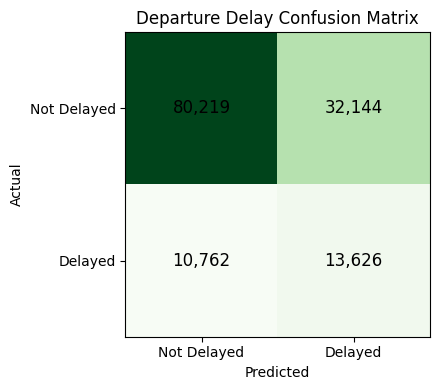

80,219 flights were correctly predicted as not delayed (True Negative)
32,144 flights were wrongly predicted as delayed when they were not (False Positive)
10,762 flights were actually delayed but we missed them (False Negative)
13,626 flights were correctly predicted as delayed (True Positive)


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split


# Load data
df = pd.read_csv("/content/drive/MyDrive/atl_joined_weather_flights_2024.csv", low_memory=False)

features = ["month", "op_unique_carrier", "origin", "dest", "sched_dep_hour",
            "distance", "weather_severity_flag", "Precip_Total_in", "Wind_Avg_mph"]

df_model = df[features + ["dep_delayed_15", "arr_delayed_15", "cancelled"]].dropna()

# Get predictions
X = df_model[features]
y = df_model["dep_delayed_15"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_prob = dep_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= dep_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Greens")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Delayed", "Delayed"])
ax.set_yticklabels(["Not Delayed", "Delayed"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Departure Delay Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/cm_departure.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{tn:,} flights were correctly predicted as not delayed (True Negative)")
print(f"{fp:,} flights were wrongly predicted as delayed when they were not (False Positive)")
print(f"{fn:,} flights were actually delayed but we missed them (False Negative)")
print(f"{tp:,} flights were correctly predicted as delayed (True Positive)")

# **Arrival Delay Confusion Matrix**

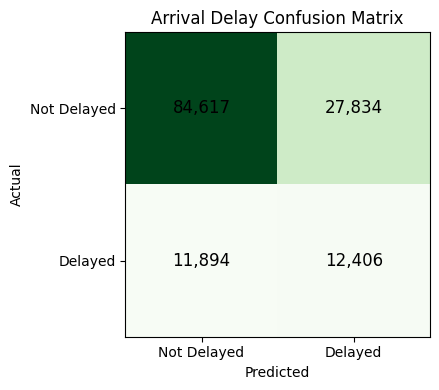

84,617 flights were correctly predicted as not delayed (True Negative)
27,834 flights were wrongly predicted as delayed when they were not (False Positive)
11,894 flights were actually delayed but we missed them (False Negative)
12,406 flights were correctly predicted as delayed (True Positive)


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model["arr_delayed_15"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_prob = arr_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= arr_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Greens")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Delayed", "Delayed"])
ax.set_yticklabels(["Not Delayed", "Delayed"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Arrival Delay Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/cm_arrival.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{tn:,} flights were correctly predicted as not delayed (True Negative)")
print(f"{fp:,} flights were wrongly predicted as delayed when they were not (False Positive)")
print(f"{fn:,} flights were actually delayed but we missed them (False Negative)")
print(f"{tp:,} flights were correctly predicted as delayed (True Positive)")

# **Cancellation Confusion Matrix**

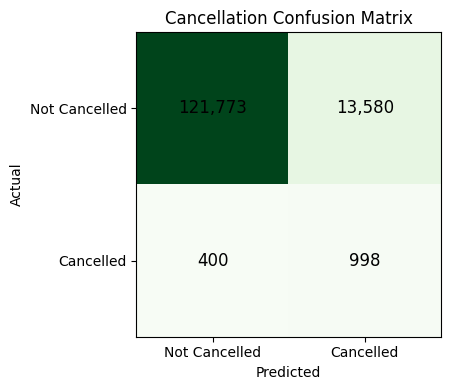

121,773 flights were correctly predicted as not cancelled (True Negative)
13,580 flights were wrongly predicted as cancelled when they were not (False Positive)
400 flights were actually cancelled but we missed them (False Negative)
998 flights were correctly predicted as cancelled (True Positive)


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model["cancelled"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_prob = cancel_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= cancel_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Greens")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Cancelled", "Cancelled"])
ax.set_yticklabels(["Not Cancelled", "Cancelled"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Cancellation Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/cm_cancellation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{tn:,} flights were correctly predicted as not cancelled (True Negative)")
print(f"{fp:,} flights were wrongly predicted as cancelled when they were not (False Positive)")
print(f"{fn:,} flights were actually cancelled but we missed them (False Negative)")
print(f"{tp:,} flights were correctly predicted as cancelled (True Positive)")